# Creation of the TSS Activity and Rotation Catalog

In [1]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import pickle
from PyAstronomy import pyasl

import warnings

# Raise error for pandas parser warning 
warnings.filterwarnings(
    "error",category=pd.errors.ParserWarning
)

#import os

# Get the catalogs

Manually identify the catalogs to cross-match, then programatically load them all as pandas dataframes into a dictionary.

### All the data tables

In [2]:
# Dictionary containing relevant information for each catalog
# bibcode: ADS bibcode
# file_path: string containing path to the file
# col_name: string containing name of the column to be used for matching (typically hpic_name or star_name)
# index: bool indicating whether the csv file includes an index column
# no underscores plz

catalogs = { \
    'avonEiff12': {'bibcode': '2012A&A...542A.116A', 'file_path': 'vsini_catalogs/Ammler-vonEiff2012.csv', 'col_name': 'star_name', 'index':False},
    'baliunas95': {'bibcode': '1995ApJ...438..269B', 'file_path': 'catalogs/Baliunas1995.csv', 'col_name': 'star_name', 'index':False},
    'baum22': {'bibcode': '2022AJ....163..183B', 'file_path': 'catalogs/Baum2022.csv', 'col_name': 'star_name', 'index':True},
    'borisov23': {'bibcode': '2023ApJS..266...11B', 'file_path': 'vsini_catalogs/Borisov2023.csv', 'col_name': 'star_name', 'index':False},
    'boyle26': {'bibcode': '2026arXiv260305586B', 'file_path': 'rotation_catalogs/boyle26_tars_v2.csv', 'col_name':'hpic_name', 'index':False},
    'bsaikia18': {'bibcode': '2018A&A...616A.108B', 'file_path': 'catalogs/20241216.HWO.Boro18.merge.csv', 'col_name': 'star_name', 'index': False},
    'bsaikia18-2': {'bibcode': '2018A&A...616A.108B', 'file_path': 'rotation_catalogs/boro18_tableA2.csv', 'col_name':'hpic_name', 'index':False},
    'briegal22': {'bibcode':'2022MNRAS.513..420B', 'file_path': 'rotation_catalogs/briegal22_ngts.csv', 'col_name':'hpic_name', 'index':False},
    'brewer16': {'bibcode': '2016ApJS..225...32B', 'file_path': 'vsini_catalogs/Brewer2016.csv', 'col_name': 'star_name', 'index':False},
    'christy22': {'bibcode': '2022PASP..134b4201C', 'file_path': 'rotation_catalogs/christy22_asas-sn.csv', 'col_name': 'hpic_name', 'index': False},
    'cincunegui07': {'bibcode': '2007A&A...469..309C', 'file_path': 'catalogs/20241216.HWO.Cincunegui2007.merge.csv', 'col_name': 'star_name', 'index': False},
    'csilva20': {'bibcode': '2020A&A...634A.136C', 'file_path': 'vsini_catalogs/CostaSilva2020.csv', 'col_name': 'star_name', 'index':False},
    'distefano23': {'bibcode':'2023A%26A...674A..20D', 'file_path': 'rotation_catalogs/distefano23_gaiadr3.csv', 'col_name':'hpic_name', 'index':False},
    'fetherolf23': {'bibcode': '2023ApJS..268....4F', 'file_path': 'rotation_catalogs/fetherolf23_tess-svc_v2.csv', 'col_name': 'hpic_name', 'index':False},
    'gsilva21': {'bibcode': '2021A&A...646A..77G', 'file_path': 'catalogs/ambre_with_dr3id.csv', 'col_name': 'gaia_dr3_id', 'index': True},
    'hempelmann16': {'bibcode': '2016A&A...586A..14H', 'file_path': 'catalogs/Hempelmann2016.csv', 'col_name': 'star_name', 'index': False},
    'henry96': {'bibcode': '1996AJ....111..439H', 'file_path': 'catalogs/20241216.HWO.Henry96.merge.csv', 'col_name': 'star_name', 'index': False},
    'hinkel17': {'bibcode': '2017ApJ...848...34H', 'file_path': 'catalogs/Hinkel2017.csv', 'col_name': 'star_name', 'index': True},
    'holmberg07': {'bibcode': '2007A&A...475..519H', 'file_path': 'vsini_catalogs/20241216.HWO.Holmberg2007.merge.csv', 'col_name': 'star_name', 'index': False},
    'isac24-2': {'bibcode': '2024ApJS..274...35I', 'file_path': 'catalogs/isaacson24_clsv_table2_AvgActivity.csv', 'col_name': 'hpic_name', 'index':False},
    'isac24-4': {'bibcode': '2024ApJS..274...35I', 'file_path': 'catalogs/isaacson24_clsv_table4_ActivityCycles.csv', 'col_name': 'hpic_name', 'index':False},
    'luck17elodie': {'bibcode': '2017AJ....153...21L-ELODIE', 'file_path': 'vsini_catalogs/Luck2017_ELODIE.csv', 'col_name': 'star_name', 'index':False},
    'luck17het': {'bibcode': '2017AJ....153...21L-HET', 'file_path': 'vsini_catalogs/Luck2017_HET.csv', 'col_name': 'star_name', 'index':False},
    'luck17sandiford': {'bibcode': '2017AJ....153...21L-San', 'file_path': 'vsini_catalogs/Luck2017_Sandiford.csv', 'col_name': 'star_name', 'index':False},
    'maldonado22': {'bibcode': '2022A&A...663A.142M', 'file_path': 'vsini_catalogs/Maldonado2022.csv', 'col_name': 'star_name', 'index':False},
    'marnaiz10feros': {'bibcode': '2010A&A...520A..79M-FEROS', 'file_path': 'vsini_catalogs/MartinezArnaiz2010_FEROS.csv', 'col_name': 'star_name', 'index':False},
    'marnaiz10foces': {'bibcode': '2010A&A...520A..79M-FOCES', 'file_path': 'vsini_catalogs/MartinezArnaiz2010_FOCES.csv', 'col_name': 'star_name', 'index':False},
    'marnaiz10mcdonald': {'bibcode': '2010A&A...520A..79M-McD', 'file_path': 'vsini_catalogs/MartinezArnaiz2010_McDonald.csv', 'col_name': 'star_name', 'index':False},
    'marnaiz10sarg': {'bibcode': '2010A&A...520A..79M-SARG', 'file_path': 'vsini_catalogs/MartinezArnaiz2010_SARG.csv', 'col_name': 'star_name', 'index':False},
    'meunier22': {'bibcode': '2022A&A...658A..57M', 'file_path': 'catalogs/Meunier2022.csv', 'col_name': 'star_name', 'index': True},
    'mittag17': {'bibcode': '2017A&A...607A..87M', 'file_path': 'catalogs/Mittag2017.csv', 'col_name': 'star_name', 'index': False},
    'oelkers18': {'bibcode':'2018AJ....155...39O', 'file_path': 'rotation_catalogs/oelkers18_kelt.csv', 'col_name':'hpic_name', 'index':False},
    'olah16': {'bibcode': '2016A&A...590A.133O', 'file_path': 'catalogs/Olah2016.csv', 'col_name': 'star_name', 'index': True},
    'rainer23': {'bibcode': '2023A&A...676A..90R', 'file_path': 'vsini_catalogs/Rainer2023.csv', 'col_name': 'star_name', 'index':False},
    'rice20': {'bibcode': '2020ApJ...898..119R',  'file_path': 'vsini_catalogs/20241216.HWO.Rice2020.merge.csv', 'col_name': 'star_name', 'index': False},
    'santos19': {'bibcode': '2019ApJS..244...21S', 'file_path': 'rotation_catalogs/santos19.csv', 'col_name': 'hpic_name', 'index':False},
    'schroder09': {'bibcode': '2009A&A...493.1099S', 'file_path': 'vsini_catalogs/Schroder2009.csv', 'col_name': 'star_name', 'index': True},
    'soto18': {'bibcode': '2018A&A...615A..76S', 'file_path': 'vsini_catalogs/Soto2018.csv', 'col_name': 'star_name', 'index':False},
    'smascareno15': {'bibcode': '2015MNRAS.452.2745S', 'file_path': 'catalogs/SuarezMascareno2015.csv', 'col_name': 'star_name', 'index': False},
    'teklu25': {'bibcode': '2025A&A...702A..68T', 'file_path': 'catalogs/Teklu2025.csv', 'col_name': 'star_name', 'index': False},
    'watson06': {'bibcode': '2006SASS...25...47W', 'file_path': 'rotation_catalogs/watson06_vsx.csv', 'col_name': 'hpic_name', 'index': False},
    'white07': {'bibcode': '2007AJ....133.2524W', 'file_path': 'catalogs/White2007_fix.csv', 'col_name': 'star_name', 'index': False},
    'wright04': {'bibcode': '2004ApJS..152..261W', 'file_path': 'catalogs/Wright2004.csv', 'col_name': 'TIC', 'index':False},
    'zakhozhay22': {'bibcode': '2022A&A...667A..63Z', 'file_path': 'vsini_catalogs/Zakhozhay2022.csv', 'col_name': 'star_name', 'index':False},
    'zhang24': {'bibcode': '2024A&A...688A..23Z', 'file_path': 'catalogs/Zhang2024.csv', 'col_name':'gaiaDR3', 'index':False},
    'zorec12': {'bibcode': '2012A&A...537A.120Z', 'file_path': 'vsini_catalogs/Zorec2012.csv', 'col_name': 'star_name', 'index':False}
    }


### Load and store them in a dataframe

In [3]:
# Dictionary to store dataframes
dataframes = {}

# Loop through the catalogs and read data into dictionary
for key in catalogs.keys():
    # Extract parameters for file
    file_name = catalogs[key]['file_path']
    print(file_name)
    if catalogs[key]['index']:
        index_col=0
    else:
        index_col=False
    # Load the dataframes and add it to the dictionary
    if key in ('zhang24', 'gsilva21'):
        dataframes[key] = pd.read_csv(file_name, index_col=index_col, sep=',', comment='#',
                                      dtype={catalogs[key]['col_name']: 'Int64'})
    else:
        dataframes[key] = pd.read_csv(file_name, index_col=index_col, sep=',', comment='#')
    # Append study name to end of column names
    dataframes[key].rename(columns={col: f"{col}_"+key for col in dataframes[key].columns},
                             inplace=True)



# Object, dunno why
dataframes['smascareno15']['star_name_smascareno15'] = dataframes['smascareno15']['star_name_smascareno15'].astype('string')
#dataframes['mittag17']['star_name_mittag17'] = dataframes['mittag17']['star_name_mittag17'].astype('string')
dataframes['hempelmann16']['Prot[d]_hempelmann16'] = dataframes['hempelmann16']['Prot[d]_hempelmann16'].astype('float')

# Add the spaces in to the TIC numbers in Wright 04
dataframes['wright04']['TIC_wright04'] = 'TIC '+dataframes['wright04']['TIC_wright04'].astype('str')

# Fix spaces for NaNs
dataframes['wright04']['GSVal_wright04'] = pd.to_numeric(dataframes['wright04']['GSVal_wright04'], errors='coerce')
dataframes['wright04']["log(R'HK)_wright04"] = pd.to_numeric(dataframes['wright04']["log(R'HK)_wright04"], errors='coerce')
dataframes['wright04']["Per_wright04"] = pd.to_numeric(dataframes['wright04']["Per_wright04"], errors='coerce')
dataframes['watson06']["period(d)_watson06"] = pd.to_numeric(dataframes['watson06']["period(d)_watson06"], errors='coerce')

# Uses zeros as empty values :(
dataframes['gsilva21'] = dataframes['gsilva21'].replace(0, np.nan)

# Remove entries for vsini that are upper limits
#Note (2)  : the flag qualifies a problem as follows:
#0 =	upper limit (<);
#1 =	no limit;
#8 =	Spectrum was corrupted;
#: =	vsini value thought to be biased (see Section 4.2).
#dataframes['white07']['u_vsini_white07'] = dataframes['white07']['u_vsini_white07'].replace(['1:','0:'], -1)
#dataframes['white07']['u_vsini_white07'] = pd.to_numeric(dataframes['white07']['u_vsini_white07'])
#dataframes['white07'][dataframes['white07']['u_vsini_white07'] == 0] = np.nan


#dataframes['brewer16']['logRHK_brewer16'][dataframes['brewer16']['logRHK_brewer16']>-2] = np.nan

# These long periods are definitely not right
mask = dataframes['christy22']['period_var(d)_christy22'] > 180
dataframes['christy22'] = dataframes['christy22'].drop(index=dataframes['christy22'].index[mask])
dataframes['christy22'] = dataframes['christy22'].reset_index(drop=True)

# Exclude negative values
mask = dataframes['rice20']['vsini_rice20'] < 0.
dataframes['rice20'] = dataframes['rice20'].drop(index=dataframes['rice20'].index[mask])
dataframes['rice20'] = dataframes['rice20'].reset_index(drop=True)

# Exclude 0.1
mask = dataframes['brewer16']['vsini_brewer16'] == 0.1
dataframes['brewer16'] = dataframes['brewer16'].drop(index=dataframes['brewer16'].index[mask])
dataframes['brewer16'] = dataframes['brewer16'].reset_index(drop=True)

# Errors for they are missing
# Holmberg error based on comparison with brewer16 (highest ranking best overlap)
dataframes['rice20']['e_vsini_rice20'] = 0.98
dataframes['holmberg07']['e_vsini_holmberg07'] = 1.1 


vsini_catalogs/Ammler-vonEiff2012.csv
catalogs/Baliunas1995.csv
catalogs/Baum2022.csv
vsini_catalogs/Borisov2023.csv
rotation_catalogs/boyle26_tars_v2.csv
catalogs/20241216.HWO.Boro18.merge.csv
rotation_catalogs/boro18_tableA2.csv
rotation_catalogs/briegal22_ngts.csv
vsini_catalogs/Brewer2016.csv
rotation_catalogs/christy22_asas-sn.csv
catalogs/20241216.HWO.Cincunegui2007.merge.csv
vsini_catalogs/CostaSilva2020.csv
rotation_catalogs/distefano23_gaiadr3.csv
rotation_catalogs/fetherolf23_tess-svc_v2.csv
catalogs/ambre_with_dr3id.csv
catalogs/Hempelmann2016.csv
catalogs/20241216.HWO.Henry96.merge.csv
catalogs/Hinkel2017.csv
vsini_catalogs/20241216.HWO.Holmberg2007.merge.csv
catalogs/isaacson24_clsv_table2_AvgActivity.csv
catalogs/isaacson24_clsv_table4_ActivityCycles.csv
vsini_catalogs/Luck2017_ELODIE.csv
vsini_catalogs/Luck2017_HET.csv
vsini_catalogs/Luck2017_Sandiford.csv
vsini_catalogs/Maldonado2022.csv
vsini_catalogs/MartinezArnaiz2010_FEROS.csv
vsini_catalogs/MartinezArnaiz2010_FOCES

### Get the HPIC

Read in the HPIC, and cross-match.

In [4]:
# this is the TSS25 list with the tiered rankings (v1): https://zenodo.org/records/17195128
HPIC_ranking = pd.read_csv('HPIC/HPIC_TSS25.csv', sep=',', dtype={'gaia_dr3_id': 'Int64'})
print(len(HPIC_ranking))
# this is Noah's original list, which contains all the stellar data
HPIC_full = pd.read_csv('HPIC/HPIC_full_2024.tsv', comment='#', sep='|')
print(len(HPIC_full))
# some names have changed, and differences in last digits of the positions, so this doesn't work:
#merged_HPIC = HPIC_full.merge(HPIC_ranking,right_on=['ra','dec'], left_on=['RAJ2000','DEJ2000'])
#merged_HPIC.head()
#print(len(merged_HPIC))

12944
12944


In [5]:
HPR = HPIC_ranking.sort_values(by=['ra','dec']).reset_index(drop=True)
HPF = HPIC_full.sort_values(by=['RAJ2000','DEJ2000']).reset_index(drop=True)
merged_HPIC = pd.concat( [ HPR, HPF ], axis=1)
print(len(merged_HPIC))
for col in ['Vmag','Bmag','Teff']:
    merged_HPIC[col] = (
        merged_HPIC[col]
        .replace(r'^\s*$', np.nan, regex=True)   # turn '' or '   ' into NaN
        .astype(float)                           # convert to float
    )
print(len(merged_HPIC))


12944
12944


# Perform cross-match between HPIC and catalogs

In [6]:
for key in catalogs.keys():
    df = dataframes[key].copy()
    col_name = catalogs[key]['col_name']+'_'+key
    if 'gaia' in col_name:
        match_col = 'gaia_dr3_id'
    else:
        match_col = 'star_name'
    if key in ['wright04', 'schroder09', 'brewer16']: # drop additional entries when multiple are present 
        df = df.drop_duplicates(subset=col_name, keep='first')
    #print(key, merged_HPIC[match_col].dtype, df[col_name].dtype)

    # Convert both columns to string (object)
    merged_HPIC[match_col] = merged_HPIC[match_col].astype(str)    
    df[col_name] = df[col_name].astype(str)

    merged_HPIC = merged_HPIC.merge(df,
                                    left_on=match_col,
                                    right_on=col_name,
                                    how='left')
    
    # track down the duplicates
    unique_exep = np.unique(merged_HPIC.star_name)
    if len(merged_HPIC) != len(HPIC_full):
        print("======="+key+"=======")
        print(merged_HPIC['star_name'][merged_HPIC.duplicated(subset=['star_name'])])

    merged_HPIC = merged_HPIC.reset_index(drop=True)

In [7]:
print(f"{key}: merged_HPIC.shape={merged_HPIC.shape}, df.shape={df.shape}")
print(f"{key}: merged_HPIC[{match_col}].nunique()={merged_HPIC[match_col].nunique()}")
print(f"{key}: df[{col_name}].nunique()={df[col_name].nunique()}")

zorec12: merged_HPIC.shape=(12944, 1072), df.shape=(179, 4)
zorec12: merged_HPIC[star_name].nunique()=12944
zorec12: df[star_name_zorec12].nunique()=179


### Unit conversions required

In [8]:
def delta_mag_to_ppm(delta_magnitude):
    """
    Convert delta magnitude to parts per million (ppm).

    Parameters:
    - delta_magnitude (float): The delta magnitude value.

    Returns:
    - The equivalent change in flux in ppm (float).
    """
    # Calculate the relative change in flux
    delta_flux = 10 ** (-0.4 * delta_magnitude)
    
    # Convert to ppm
    ppm = delta_flux * 1e6  # Multiply by 1,000,000 to convert to ppm
    
    return ppm

merged_HPIC['amp(ppm)_christy22'] = delta_mag_to_ppm(merged_HPIC['amp(mag)_christy22']) # Convert to ppm from mag
merged_HPIC['amp_g(ppm)_distefano23'] = delta_mag_to_ppm(merged_HPIC['amp_g(mag)_distefano23']) #convert to ppm from mag

merged_HPIC['Amplitude(ppm)_briegal22'] = merged_HPIC["Amplitude(%)_briegal22"] * 1e4  # Convert to ppm from %
merged_HPIC['amp_median(ppm)_boyle26'] = merged_HPIC["amp_median(%)_boyle26"] * 1e4  # Convert to ppm from %



# Adopt a single value for each parameters

The lists below compile all of the different measurements available. The order should be the order of preference of the surveys, e.g. if a survey comes first in the list it will be preferentially adopted.

### Order of preference

In [9]:
# Columns Indicating S-index (Mt. Wilson Survey)
s_index_columns = [ 
    "S_value_median_baum22",
    "S_value_median_teklu25",
    "Smedian_isac24-2",
    "SMWmed_gsilva21",
    "Smed_bsaikia18",
    "S_Value_brewer16",
    "GSVal_wright04",
    "S_cl_schroder09",
    "S_white07",
    "S_MW__henry96",
    "__S__cincunegui07",
    "SMWO_zhang24"
]

for col in s_index_columns:
    #print(merged_HPIC.loc[merged_HPIC[col] > 2, col])
    merged_HPIC.loc[merged_HPIC[col] > 2, col] = np.nan


# Columns Indicating R'HK Index 
rhk_columns = [ 
    "logrhk_median_teklu25",
    "log(Rhk)_isac24-2",
    "logRHKmed_gsilva21",
    "logRhk_meunier22",
    "logRHK_brewer16",
    "log(R'HK)_wright04",
    "logRhk_cl_schroder09",
    "RHK_white07",
    "logRHKcl_zhang24",
    "logRHK_hinkel17",
]

# Columns Indicating vsini (Projected Rotational Velocity) 
vsini_columns = [
    "vsini_soto18",
    "vsini_csilva20",
    "vsini_maldonado22",
    "vsini_rainer23",
    "vsini_borisov23",
    "vsini_brewer16",
    "vsini_rice20",
    "vsini_luck17sandiford",
    "vsini_marnaiz10sarg",
    "vsini_marnaiz10mcdonald",
    "vsini_avonEiff12",
    "vsini_zakhozhay22",
    "vsini_marnaiz10feros",
    "vsini_luck17elodie",
    "vsini_marnaiz10foces",
    "vsini_luck17het",
    "vsini_schroder09",
    "vsini_holmberg07",
    "vsini_zorec12",
    "vsini_white07"
]

# Columns Indicating Rotation Period 
rotation_period_columns = [
    "period_var(d)_christy22",
    "period(d)_oelkers18",
    "Prot(d)_santos19",
    "period(d)_watson06",
    "period(days)_briegal22",
    "Prot(d)_distefano23",
    "period_rot(d)_boyle26",
    "period_var(d)_fetherolf23",
    "Prot(d)_bsaikia18-2",
    "Prot[d]_olah16",
    "Prot[d]_smascareno15",
    "Prot[d]_mittag17",
    "Prot[d]_hempelmann16"
]


# Columns Indicating Activity Cycle Period 
activity_cycle_columns = [
    "Pcycle(yr)_isac24-4",
    "cycle[yr]_baum22",
    "Pcyc(yr)_bsaikia18-2",
    "cycle[years]_baliunas95"
]


# Columns Indicating Photometry Jitter 
phot_jitter_columns = [
    "amp(ppm)_christy22",
    "Sph(ppm)_santos19",
    "Amplitude(ppm)_briegal22",
    "amp_g(ppm)_distefano23",
    "amp_median(ppm)_boyle26",
    "amp_var(ppm)_fetherolf23"
]


### Function to do the selecting

In [10]:
def select_value(df, columns, value_selected, value_ref, error_col=False):
    """
    Create 'value_selected' and 'value_ref' columns in the DataFrame.

    Parameters:
    - df: pandas dataframe
    - columns: list of strings, names of the columns to consider for selection.
            Order sets order of preference.
    - value_selected: name of column to be created with selected values.
    - value_ref: name of column to be created with references for selected values.

    Returns:
    - The modified DataFrame with new columns 'value_selected' and 'value_ref'.
    """

    # Create selected_series from 1st provided column
    col = columns[0]
    selected_series = df[col].copy().astype('float')


    # Iterate through the remaining columns, filling NaNs where possible
    for col in columns[1:]:
        selected_series = selected_series.combine_first(df[col])

    # Extract only the part of the string after the last underscore
    cat_keys = [cc.rsplit('_', 1)[-1] for cc in columns]

    # Corresponding bibcodes
    bibcodes = [
        catalogs.get(k, {}).get("bibcode", np.nan) for k in cat_keys
    ]
        
    # Identify mask
    conditions = [df[cc].notna() for cc in columns]

    # Create the references column
    reference_series = np.select(conditions, bibcodes, default="nan")

    df = df.assign(**{value_selected: selected_series,
                        value_ref: reference_series})
    if error_col:
        error_values = [df['e_' + cc] for cc in columns]
        error_series = np.select(conditions, error_values, default="nan")
        df = df.assign(**{'e_' + value_selected: error_series})

    #print(value_selected, selected_series)
    print(len(df))
    return df



### Do the selecting

In [11]:
merged_HPIC = select_value(merged_HPIC, s_index_columns, 'S_index_adopt', 'r_S_index_adopt')
merged_HPIC = select_value(merged_HPIC, rhk_columns, 'RHK_adopt', 'r_RHK_adopt')
merged_HPIC = select_value(merged_HPIC, vsini_columns, 'vsini_adopt', 'r_vsini_adopt', error_col=True)
merged_HPIC = select_value(merged_HPIC, rotation_period_columns, 'prot_adopt', 'r_prot_adopt')
merged_HPIC = select_value(merged_HPIC, activity_cycle_columns, 'act_cycle_adopt', 'r_act_cycle')
merged_HPIC = select_value(merged_HPIC, phot_jitter_columns, 'phot_jitter_adopt', 'r_phot_jitter')

12944
12944
12944
12944
12944
12944


# Ca H&K 

Create uniform Ca H&K values

### PyAstro implementation

This is only for stars 0.44 < B-V < 0.82, although most extend to 1.6 (which we will do here).

In [12]:
%%capture

ss = pyasl.SMW_RHK()

def calc_rhk(row):

    if pd.isna(row['S_index_adopt']) or pd.isna(row['Teff']) or pd.isna(row['Bmag']) or pd.isna(row['Vmag']):
        return pd.Series([np.nan], index=['RHK_calculated_pyastro'])

    bv = row['Bmag'] - row['Vmag']
    
    if (bv<0.44) or (bv>1.2) or (row['Teff']<4000): #noyes
        return pd.Series([np.nan], index=['RHK_calculated_pyastro'])
    
    rhk, _, _, _, _, _ = ss.SMWtoRHK(row['S_index_adopt'], row['Teff'], row['Bmag'] - row['Vmag'],
                          lc="ms", verbose=False)
    logrhk=np.log10(rhk)
        
    return pd.Series([logrhk], index=['RHK_calculated_pyastro'])

merged_HPIC[['RHK_calculated_pyastro']] = merged_HPIC.apply(calc_rhk, axis=1)

### Marvin23 calibration

This is calculated from Teff and so is easier to apply more broadly.
Reference: 
https://ui.adsabs.harvard.edu/abs/2023A%26A...671A.162M/abstract

In [13]:
def calc_Rprime_HK(S, Teff):
    
    #K = 1.07e6 # erg cm^-2 s^-1
    #sigmaSB = 5.6704e-5 # erg cm^-2 s^-1 K^-4

    # https://www.aanda.org/articles/aa/full_html/2023/03/aa37306-19/T3.html
    logRHKphot = np.poly1d([1.0887E-17, -2.7466E-13, 2.7133E-09, -1.3177E-05, 3.2131E-02, -3.7550E+01])
    Rphot = 10.**(logRHKphot(Teff) -0.4612) # scale to Noyes per Sec 4.5
    
    #https://www.aanda.org/articles/aa/full_html/2023/03/aa37306-19/T2.html
    logCCf = np.poly1d([7.1548E-18, -1.9017E-13, 1.9866E-09, -1.0268E-05, 2.6864E-02, -2.9679E+01])    
    Ccf = 10.**logCCf(Teff)
    
    #Rprime = K*(sigmaSB**-1)*(1e-14)*Ccf*S - Rphot
    Rprime = 1.34e-4*Ccf*S - Rphot
    Rprime[(Teff>7200.) | (Teff<2200.) | (np.log10(Rprime)<-5.5)] = np.nan # two weirdos

    return np.log10(Rprime)

RHK_calculated = calc_Rprime_HK(merged_HPIC['S_index_adopt'],merged_HPIC['Teff'])
merged_HPIC['RHK_calculated_marvin23'] = RHK_calculated

/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_94607/3376398800.py:8: RuntimeWarning: overflow encountered in power
  Rphot = 10.**(logRHKphot(Teff) -0.4612) # scale to Noyes per Sec 4.5
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_94607/3376398800.py:12: RuntimeWarning: overflow encountered in power
  Ccf = 10.**logCCf(Teff)
/opt/homebrew/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_94607/2379196620.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


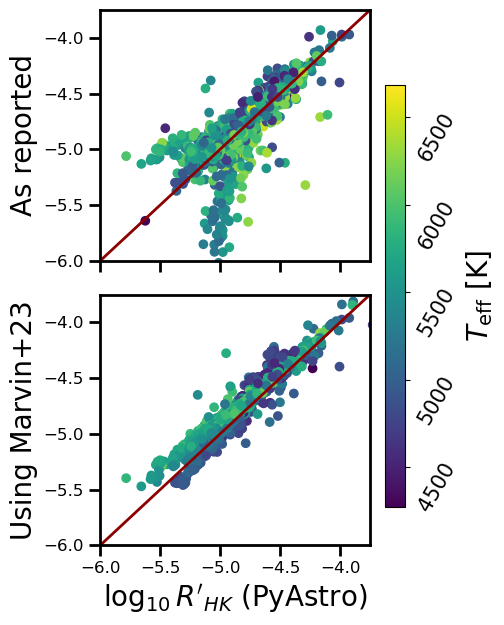

In [14]:
import matplotlib as mpl
mpl.rcParams['font.size'] = 15
mpl.rcParams['axes.labelsize'] = 20

fig, axes = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(5, 6.5))
for ax in axes:
    ax.plot([-6,-3],[-6,-3], c='darkred', lw=2)

# First scatter plot
sc0 = axes[0].scatter(
    merged_HPIC['RHK_calculated_pyastro'], 
    merged_HPIC['RHK_adopt'], 
    c=merged_HPIC['Teff'], cmap='viridis'
)
axes[0].set_ylabel('As reported')

# Second scatter plot
sc1 = axes[1].scatter(
    merged_HPIC['RHK_calculated_pyastro'], 
    merged_HPIC['RHK_calculated_marvin23'], 
    c=merged_HPIC['Teff'], cmap='viridis'
)
axes[1].set_xlabel(r"$\log_{10}{R'_{HK}}$ (PyAstro)")
axes[1].set_ylabel('Using Marvin+23')

# Adjust subplots to leave space on top for colorbar

# Create an axis for the colorbar on top:
cbar_ax = fig.add_axes([0.77, 0.2, 0.04, 0.65])  # [left, bottom, width, height] in figure coords
cbar_ax.tick_params(rotation=60)

for ax in axes:
    ax.set_xlim(-6, -3.75)
    ax.set_ylim(-6, -3.75)
    ax.tick_params(length=8, width=2, labelsize=12, direction='out')
    for xx in ['top','bottom','left','right']:
        ax.spines[xx].set_linewidth(2)
    
# Add the colorbar into this axis
cbar = fig.colorbar(sc0, cax=cbar_ax, orientation='vertical')
cbar.set_label(r'$T_\mathrm{eff}$ [K]')

plt.tight_layout()
fig.subplots_adjust(right=0.74, left=0.2)

plt.savefig('rhk-verification.png', dpi=300)

# Summary statistics

# Write out the final catalog

In [15]:
merged_HPIC[['star_name', 'Teff', 'vsini_adopt', 'S_index_adopt', 'RHK_adopt','RHK_calculated_marvin23', 'RHK_calculated_pyastro']][merged_HPIC['TSS_tier']==1]

,star_name,Teff,vsini_adopt,S_index_adopt,RHK_adopt,RHK_calculated_marvin23,RHK_calculated_pyastro
70,TIC 238432056,5491.0,4.10,0.40740,-4.304547,-4.379021,-4.440419
102,TIC 289673491,6190.0,4.88,0.14970,-4.940000,-4.859777,-4.907439
108,TIC 70847587,6533.3,4.05,0.14400,NaN,-4.859478,NaN
198,TIC 425935521,5932.0,0.00,0.17900,-4.930000,-4.760079,-4.833073
255,TIC 267211065,5806.0,6.00,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
12434,TIC 155315739,3676.3,NaN,1.29480,-4.782040,-4.699577,NaN
12520,TIC 283722336,4874.0,1.64,0.25525,-4.859385,-4.889797,-4.911020
12554,TIC 24467943,6084.0,4.70,0.13575,-5.010000,-4.979134,-4.993149
12556,TIC 234968549,6280.0,8.80,NaN,-4.420000,NaN,NaN


In [16]:
merged_HPIC['Age'] = pd.to_numeric(merged_HPIC['Age'], errors='coerce')
merged_HPIC['Ksmag'] = pd.to_numeric(merged_HPIC['Ksmag'], errors='coerce')

# https://iopscience.iop.org/article/10.1088/0004-637X/741/1/54#apj404215s4 eq 36
tau_cranmer11 = 314.24 * np.exp(-(merged_HPIC['Teff']/1952.5) - (merged_HPIC['Teff']/6250.)**18 ) + 0.002
merged_HPIC['tau_cranmer11'] = tau_cranmer11

# as reported in https://www.aanda.org/articles/aa/pdf/2021/08/aa41395-21.pdf
x = 1 - (merged_HPIC['Bmag'] - merged_HPIC['Vmag'])
tau_noyes84 = pd.Series(np.nan, index=merged_HPIC.index)
tau_noyes84[x>=0] = 1.362 - 0.166*x + 0.025*x**2 - 5.323*x**3 
tau_noyes84[x<0] = 1.362 - 0.14*x 

# https://www.aanda.org/articles/aa/pdf/2021/08/aa41395-21.pdf
x = pd.to_numeric(merged_HPIC['BPmag'], errors='coerce') - pd.to_numeric(merged_HPIC['RPmag'], errors='coerce')
tau_corsaro21 = -134 + 341.7*x - 150.6*x**2
tau_corsaro21[x<0.55] = np.nan
tau_corsaro21[x>0.97] = np.nan
merged_HPIC['tau_corsaro21'] = tau_corsaro21

merged_HPIC[['star_name','TSS_tier','ra','dec','Teff', 'sy_dist', 'Vmag', 'Ksmag', 'Age',
             'vsini_adopt', 'e_vsini_adopt', 'r_vsini_adopt', 
             'S_index_adopt', 'RHK_adopt', 'RHK_calculated_marvin23', 'RHK_calculated_pyastro',
             'prot_adopt', 'r_prot_adopt', 'tau_cranmer11', 
             'act_cycle_adopt', 'phot_jitter_adopt']].to_csv('TSS_ARC.csv')

In [17]:
with open('HPIC+TSS3_all_columns.pkl', 'wb') as f:
    pickle.dump((merged_HPIC, s_index_columns, rhk_columns, vsini_columns, rotation_period_columns, activity_cycle_columns, phot_jitter_columns), f)

In [18]:

df = merged_HPIC[['star_name','TSS_tier','ra','dec','Teff', 'sy_dist', 'Vmag', 'Bmag', 'Age',
             'vsini_adopt', 'e_vsini_adopt', 'r_vsini_adopt', 
             'S_index_adopt', 'RHK_adopt', 'RHK_calculated_marvin23', 'RHK_calculated_pyastro',
             'prot_adopt', 'r_prot_adopt', 'tau_cranmer11', 
             'act_cycle_adopt', 'phot_jitter_adopt']].copy()

tex_descr_file = "arc_table_descriptions.tex"
col_order = list(df.columns)          # preserve the original order


with open(tex_descr_file, "w") as f:
    f.write(r"\begin{deluxetable}{lllc}" + "\n")
    f.write(r"\tablecaption{Column description for the ARC.\label{tab:arc}}" + "\n")
    f.write(r"\tablehead{"
            r"\colhead{Column Name}&"
            r"\colhead{Units}&"
            r"\colhead{Data Type}&"
            r"\colhead{Description}&"
            r"\colhead{N1}&"
            r"\colhead{N2}&"
            r"\colhead{N3}}"+ "\n")
    f.write(r"\startdata" + "\n")
    for col in col_order:
        units = "Units"
        dtype = "Type"
        desc  = "Description"

        if col in ["star_name", "ra", "dec"] or col.startswith("r_"):
            counts = ["$\ldots$", "$\ldots$", "$\ldots$"]                        
        
        else: # Count non‑null entries for each tier
            counts = [0,0,0]
            for tier in [1,2,3]:
                n = df.loc[df["TSS_tier"] == tier, col].notna().sum()
                counts[tier-1] = int(n)                 
            
        line = f"{col} & {units} & {dtype} & {desc} & {counts[0]} & {counts[1]} & {counts[2]}\\\\"
        f.write(line + "\n")
    f.write(r"\enddata" + "\n")
    f.write(r"\end{deluxetable}" + "\n")

In [19]:
merged_HPIC = pd.read_csv('TSS_ARC.csv')
print(len(merged_HPIC))


for tier in [1,2,3]:
    
    print('"""\nTier{}\n"""'.format(tier))
    tmp = merged_HPIC[merged_HPIC['TSS_tier']==tier]
    totstars = tmp.shape[0]
    print("Number of stars in tier: %i" % tmp.shape[0])
    for key in tmp.keys():
        if ('adopt' in key) or ('calculated' in key):
            try:
                print("Number of valid rows in", key, "column:", np.sum(~np.isnan(tmp[key])), 100*np.sum(~np.isnan(tmp[key])/totstars))
            except(TypeError):
                continue


12944
"""
Tier1
"""
Number of stars in tier: 164
Number of valid rows in vsini_adopt column: 160 97.5609756097561
Number of valid rows in e_vsini_adopt column: 97 59.14634146341464
Number of valid rows in S_index_adopt column: 147 89.6341463414634
Number of valid rows in RHK_adopt column: 123 75.0
Number of valid rows in RHK_calculated_marvin23 column: 147 89.6341463414634
Number of valid rows in RHK_calculated_pyastro column: 130 79.26829268292681
Number of valid rows in prot_adopt column: 118 71.95121951219512
Number of valid rows in act_cycle_adopt column: 31 18.902439024390247
Number of valid rows in phot_jitter_adopt column: 98 59.756097560975604
"""
Tier2
"""
Number of stars in tier: 495
Number of valid rows in vsini_adopt column: 444 89.69696969696967
Number of valid rows in e_vsini_adopt column: 304 61.41414141414141
Number of valid rows in S_index_adopt column: 392 79.19191919191917
Number of valid rows in RHK_adopt column: 308 62.222222222222214
Number of valid rows in RHK_ca